In [1]:
import glob
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Loading raw files and merged them.

files = glob.glob(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\data\raw\*.csv")

dfs = []

for f in files:
    df = pd.read_csv(f, skiprows=1)
    df.columns = df.columns.str.strip()
    dfs.append(df)

df_merged = pd.concat(dfs, ignore_index=True)

print(df_merged.head())
print("\nColumns:\n", df_merged.columns)
print("\nInfo:\n", df_merged.info())

     subj  trial      time  color    condition  correct response        RT
0  118340      0  1.814140  green    congruent  correct        f  0.944198
1  118340      1  3.835822  green  incongruent  correct        f  0.794779
2  118340      2  5.855570    red  incongruent  correct        d  0.566762
3  118340      3  7.875476   blue      neutral  correct        j  0.674958
4  118340      4  9.895955  green      neutral  correct        f  1.118514

Columns:
 Index(['subj', 'trial', 'time', 'color', 'condition', 'correct', 'response',
       'RT'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   subj       51000 non-null  int64  
 1   trial      51000 non-null  int64  
 2   time       51000 non-null  float64
 3   color      51000 non-null  str    
 4   condition  51000 non-null  str    
 5   correct    51000 non-null  str    
 6   respons

In [3]:
# Validation the strucute.

# Types and shape
print("Dtypes:\n", df_merged.dtypes)
print("\nData shape: ", df_merged.shape)

# Number of trials per condition
print("\nNumber of trials:\n", df_merged["condition"].value_counts())

# Number of unique participants
print("\nParticipants: ", df_merged["subj"].nunique())

# Missing values
print("\nMissing values:\n", df_merged.isnull().sum())

Dtypes:
 subj           int64
trial          int64
time         float64
color            str
condition        str
correct          str
response         str
RT           float64
dtype: object

Data shape:  (51000, 8)

Number of trials:
 condition
congruent      16449
incongruent    16447
neutral        16413
probe           1691
Name: count, dtype: int64

Participants:  81

Missing values:
 subj         0
trial        0
time         0
color        0
condition    0
correct      0
response     0
RT           0
dtype: int64


In [4]:
# Checking RT.

df_merged["RT"] = pd.to_numeric(df_merged["RT"], errors="coerce")

print(df_merged.groupby("condition")["RT"].describe())

               count      mean       std  min       25%       50%       75%  \
condition                                                                     
congruent    16449.0  0.655516  0.279417 -1.0  0.520361  0.613710  0.763355   
incongruent  16447.0  0.731579  0.386374 -1.0  0.562673  0.712772  0.935480   
neutral      16413.0  0.670495  0.284806 -1.0  0.529153  0.634222  0.790996   
probe         1691.0 -1.000000  0.000000 -1.0 -1.000000 -1.000000 -1.000000   

                  max  
condition              
congruent    1.597732  
incongruent  1.599897  
neutral      1.596369  
probe       -1.000000  


In [5]:
# Changing -1 to nan.

df_merged["RT"] = pd.to_numeric(df_merged["RT"], errors="coerce")
df_merged = df_merged[df_merged["RT"] > 0]

# Removing invalid condition.

df_merged = df_merged[df_merged["condition"] != "probe"]

# Recomputing summaries.

print(df_merged.groupby("condition")["RT"].describe())

               count      mean       std       min       25%       50%  \
condition                                                                
congruent    16272.0  0.673524  0.220872  0.012440  0.523763  0.616308   
incongruent  16020.0  0.777733  0.266852  0.025451  0.574043  0.721489   
neutral      16225.0  0.689851  0.222134  0.011215  0.532954  0.636727   

                  75%       max  
condition                        
congruent    0.766082  1.597732  
incongruent  0.943960  1.599897  
neutral      0.793167  1.596369  


In [6]:
# Saveing merged dataset.

df_merged.to_csv(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\data\processed\stroop-merged.csv", index=False)

### Dataset Dictionary

#### subj
- meaning: participant identifier
- role: grouping variable (between-subject factor)
- type: categorical (integer-coded)
- notes: 81 unique participants; repeated-measures structure within each subject

#### trial
- meaning: trial index within participant
- role: within-subject sequencing variable
- type: integer (ordinal)
- notes: resets per participant; not globally unique

#### time
- meaning: elapsed time during experiment (trial onset or timestamp)
- role: temporal tracking variable
- type: continuous numeric (float)
- units: seconds

#### color
- meaning: stimulus ink color presented on each trial
- role: experimental stimulus feature
- type: categorical (nominal)
- values: red, green, blue, yellow (observed set)

#### condition
- meaning: Stroop experimental condition
- role: independent variable (within-subject factor)
- type: categorical (nominal)
- values: congruent, incongruent, neutral, probe

#### correct
- meaning: response accuracy label
- role: performance outcome variable
- type: categorical (binary-like)
- values: correct, incorrect

#### response
- meaning: participant keypress response
- role: behavioral response variable
- type: categorical

#### RT
- meaning: reaction time from stimulus onset to response
- role: dependent variable (primary outcome)
- type: continuous numeric
- units: seconds
- notes: cleaned from invalid values (-1 removed as NaN)

In [7]:
# Loading mereged data.

file_path = r"F:\doc-hub\education\psychology\projects\research\stroop-interference\data\processed\stroop-merged.csv"

df = pd.read_csv(file_path)

# Inspection

print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 48517 entries, 0 to 48516
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   subj       48517 non-null  int64  
 1   trial      48517 non-null  int64  
 2   time       48517 non-null  float64
 3   color      48517 non-null  str    
 4   condition  48517 non-null  str    
 5   correct    48517 non-null  str    
 6   response   48517 non-null  str    
 7   RT         48517 non-null  float64
dtypes: float64(2), int64(2), str(4)
memory usage: 3.0 MB
None
     subj  trial      time  color    condition  correct response        RT
0  118340      0  1.814140  green    congruent  correct        f  0.944198
1  118340      1  3.835822  green  incongruent  correct        f  0.794779
2  118340      2  5.855570    red  incongruent  correct        d  0.566762
3  118340      3  7.875476   blue      neutral  correct        j  0.674958
4  118340      4  9.895955  green      neutral  correct        f 

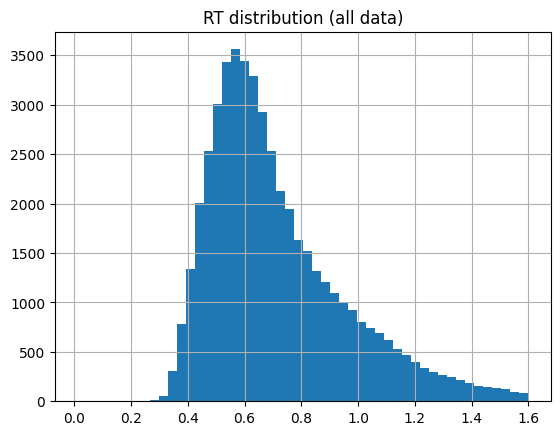

In [8]:
# Checking RT distribution.

df["RT"].hist(bins=50,)

plt.title("RT distribution (all data)")

plt.show()

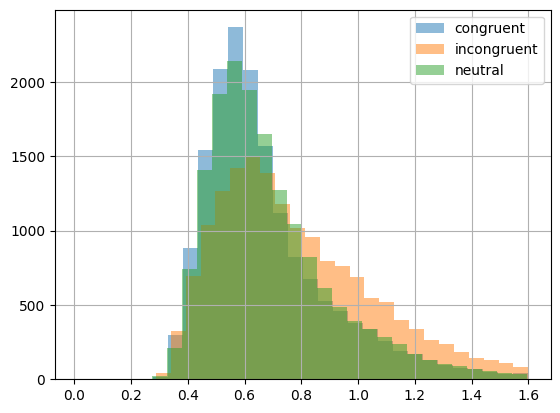

In [9]:
# Checking RT by condition distribution.

for c in df["condition"].unique():
    df[df["condition"] == c]["RT"].hist(alpha=0.5, bins=30, label=c)

plt.legend()

plt.show()

In [10]:
# Condition summary table

print(
    df.groupby("condition")["RT"].agg(["count","mean","std","median"])
)

             count      mean       std    median
condition                                       
congruent    16272  0.673524  0.220872  0.616308
incongruent  16020  0.777733  0.266852  0.721489
neutral      16225  0.689851  0.222134  0.636727


In [11]:
# Saving RT by condition.

df.groupby("condition")["RT"].mean().to_csv(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\results\rt-by-condition.csv")

In [12]:
# Accuracy analysis

pd.crosstab(df["condition"], df["correct"])

df.groupby("condition")["correct"].apply(lambda x: (x=="correct").mean())

condition
congruent      0.958641
incongruent    0.930275
neutral        0.949091
Name: correct, dtype: float64

In [13]:
# Checking participant-level sanity.

df.groupby("subj")["RT"].count().describe()

count      81.000000
mean      598.975309
std       126.539813
min       523.000000
25%       567.000000
50%       575.000000
75%       579.000000
max      1154.000000
Name: RT, dtype: float64

In [14]:
# Saveing cleaned dataset.

df.to_csv(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\data\processed\stroop-cleaned.csv", index=False)

In [15]:
# Building a file inventory for creating one row per file.

files = glob.glob(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\data\raw\*.csv")

inventory = []

for file in files:

    temp = pd.read_csv(file, skiprows=1)

    subj = temp["subj"].iloc[0]

    n_trials = len(temp)

    inventory.append({
        "subj": subj,
        "file": Path(file).name,
        "n_trials": n_trials
    })

audit = pd.DataFrame(inventory)

print(audit.head())

     subj                                   file  n_trials
0  118340  118340-stroop-mw-2018-mar-16-1411.csv       600
1  120554  120554-stroop-mw-2018-mar-12-1419.csv       600
2  142272  142272-stroop-mw-2018-mar-13-1423.csv       600
3  142610  142610-stroop-mw-2018-mar-15-1414.csv       600
4  146393  146393-stroop-mw-2018-mar-13-1423.csv       600


In [16]:
# Detecting duplicated participant.

audit["subj"].value_counts().head(20)

duplicate_ids = audit["subj"].value_counts()

duplicate_ids = duplicate_ids[duplicate_ids > 1]

print(duplicate_ids)

subj
180705    2
375537    2
639598    2
725297    2
Name: count, dtype: int64


In [17]:
# Extracting duplicated files.

print(audit[audit["subj"].isin(duplicate_ids.index)])

      subj                                    file  n_trials
7   180705   180705-stroop-mw-2018-mar-09-1122.csv       600
8   180705  180705b-stroop-mw-2018-mar-12-1419.csv       600
35  375537   375537-stroop-mw-2018-mar-14-1417.csv       600
36  375537  375537b-stroop-mw-2018-mar-15-1412.csv       600
52  639598   639598-stroop-mw-2018-mar-12-1420.csv       600
53  639598  639598b-stroop-mw-2018-mar-16-1413.csv       600
60  725297   725297-stroop-mw-2018-mar-12-1419.csv       600
61  725297  725297b-stroop-mw-2018-mar-12-1419.csv       600


In [18]:
# Recovering metadata date.

sample = pd.read_csv(files[0], header=None)

print(sample.iloc[0])

0     # OrderedDict([('code'
1                 u'118340')
2       ('alder (opsjonalt)'
3                     u'20')
4               (u'kj\xf8nn'
5                  'kvinne')
6                    ('date'
7       u'2018_mar_16_1411')
8                 ('expName'
9                'StroopMW')
10              ('frameRate'
11     59.933053921032119)])
Name: 0, dtype: str


In [19]:
# Creating extarct metadata function.

def extract_metadata(file_path):

    filename = Path(file_path).stem
    parts = filename.split("-")

    raw_subj = parts[0]

    match = re.match(r"(\d+)([a-z]?)", raw_subj)

    subj = int(match.group(1))
    session = match.group(2) if match.group(2) != "" else "A"

    date = "-".join(parts[2:])

    return subj, session, date

# Building the audit table.

audit_rows = []

for file in files:

    subj, session, date = extract_metadata(file)

    temp = pd.read_csv(file, skiprows=1)

    audit_rows.append({
        "subj": subj,
        "session": session,
        "file": Path(file).name,
        "date": date,
        "n_trials": len(temp)
    })

audit = pd.DataFrame(audit_rows)

print(audit.head())

     subj session                                   file                 date  \
0  118340       A  118340-stroop-mw-2018-mar-16-1411.csv  mw-2018-mar-16-1411   
1  120554       A  120554-stroop-mw-2018-mar-12-1419.csv  mw-2018-mar-12-1419   
2  142272       A  142272-stroop-mw-2018-mar-13-1423.csv  mw-2018-mar-13-1423   
3  142610       A  142610-stroop-mw-2018-mar-15-1414.csv  mw-2018-mar-15-1414   
4  146393       A  146393-stroop-mw-2018-mar-13-1423.csv  mw-2018-mar-13-1423   

   n_trials  
0       600  
1       600  
2       600  
3       600  
4       600  


In [20]:
# Reorgonizing the dataset.

audit = audit.sort_values(
    ["subj", "date"]
)

audit["session"] = (
    audit.groupby("subj")
    .cumcount() + 1
)

audit["included"] = ""
audit["reason"] = ""

print(audit.head())

     subj  session                                   file  \
0  118340        1  118340-stroop-mw-2018-mar-16-1411.csv   
1  120554        1  120554-stroop-mw-2018-mar-12-1419.csv   
2  142272        1  142272-stroop-mw-2018-mar-13-1423.csv   
3  142610        1  142610-stroop-mw-2018-mar-15-1414.csv   
4  146393        1  146393-stroop-mw-2018-mar-13-1423.csv   

                  date  n_trials included reason  
0  mw-2018-mar-16-1411       600                  
1  mw-2018-mar-12-1419       600                  
2  mw-2018-mar-13-1423       600                  
3  mw-2018-mar-15-1414       600                  
4  mw-2018-mar-13-1423       600                  


In [21]:
# Saving participant file audit.

audit.to_csv(
    r"F:\doc-hub\education\psychology\projects\research\stroop-interference\data\metadata\participant-file-audit.csv",
    index=False
)

In [22]:
# Descriptive inspection of participant-level QC table

qc = (
    df.groupby("subj")
    .agg(
        n_trials=("RT", "size"),
        mean_rt=("RT", "mean"),
        accuracy=("correct", lambda x: (x == "correct").mean())
    )
)

print(qc.describe())

          n_trials    mean_rt   accuracy
count    81.000000  81.000000  81.000000
mean    598.975309   0.716697   0.946663
std     126.539813   0.101317   0.034024
min     523.000000   0.519031   0.835640
25%     567.000000   0.640298   0.932409
50%     575.000000   0.699829   0.954861
75%     579.000000   0.780994   0.972318
max    1154.000000   1.018850   0.991274


In [23]:
# Identifying problematic participants.

print(qc.sort_values("accuracy").head(10))

print(qc.sort_values("mean_rt").head(10))

print(qc.sort_values("mean_rt", ascending=False).head(10))

        n_trials   mean_rt  accuracy
subj                                
959728       578  0.596155  0.835640
935666       536  0.790552  0.847015
180705      1153  0.697875  0.859497
497562       563  0.833731  0.877442
354109       554  1.018850  0.880866
197623       565  0.881228  0.884956
733206       572  0.767564  0.888112
847738       523  0.809012  0.894837
311153       574  0.600644  0.897213
684397       564  0.839725  0.898936
        n_trials   mean_rt  accuracy
subj                                
149318       580  0.519031  0.960345
288246       578  0.564331  0.963668
247620       581  0.572488  0.958692
430453       580  0.580399  0.967241
901393       578  0.585950  0.974048
190732       579  0.594780  0.979275
959728       578  0.596155  0.835640
753332       580  0.598212  0.950000
342023       580  0.598232  0.981034
311153       574  0.600644  0.897213
        n_trials   mean_rt  accuracy
subj                                
354109       554  1.018850  0.880866
9

In [24]:
# Saveing QC results.

qc.to_csv(r"F:\doc-hub\education\psychology\projects\research\stroop-interference\results\participant-qc.csv")